In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

FIGURES_DIR = Path("figures"); FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR    = "data/"

TARGET_COL = "price"

In [3]:
# Weekly price — pivoted wide by display_name
df_fruitveg        = pd.read_csv(f"{DATA_DIR}cleaned_fruit_veg.csv")
df_fruitveg["date"]  = pd.to_datetime(df_fruitveg["date"])
df_fruitveg["price"] = pd.to_numeric(df_fruitveg["price"], errors="coerce")

price_wide = (
    df_fruitveg
    .groupby(["date", "display_name"])["price"]
    .mean()
    .unstack("display_name")
    .sort_index()
    .ffill()
    .bfill()
)

weekly_idx = price_wide.index
TARGET_COL = price_wide.columns[0]   # ← update to your primary item if needed
print(f"Items: {price_wide.columns.tolist()}")

# Fuel
fuel1   = pd.read_csv(f"{DATA_DIR}weekly_road_fuel_prices_2003_to_2017.csv")
fuel2   = pd.read_csv(f"{DATA_DIR}weekly_road_fuel_prices_2018_to_now.csv")
df_fuel = pd.concat([fuel1, fuel2], ignore_index=True)
date_col = [c for c in df_fuel.columns if c.strip().lower() == "date"][0]
ulsp_col = [c for c in df_fuel.columns if "ulsp" in c.lower()][0]
df_fuel["date"]       = pd.to_datetime(df_fuel[date_col], dayfirst=True)
df_fuel["fuel_price"] = pd.to_numeric(df_fuel[ulsp_col], errors="coerce")
fuel_weekly = df_fuel[["date","fuel_price"]].dropna().set_index("date")["fuel_price"].sort_index()

# CPI
raw_cpi = pd.read_excel(
    f"{DATA_DIR}consumerpriceinflationdetailedreferencetables.xlsx",
    sheet_name="Table 15a, 15b, 15c", skiprows=5, header=0
)
raw_cpi.columns = raw_cpi.columns.str.strip()
months   = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
cpi_rows = raw_cpi[raw_cpi["Unnamed: 1"].astype(str).str.match(r"^\d{4}$", na=False)].copy()
cpi_rows = cpi_rows[["Unnamed: 1"] + months].copy()
cpi_rows.columns = ["year"] + months
cpi_rows["year"] = cpi_rows["year"].astype(int)
cpi_long = cpi_rows.melt(id_vars="year", value_vars=months, var_name="month", value_name="cpi")
cpi_long["cpi"]  = pd.to_numeric(cpi_long["cpi"].astype(str).str.strip(), errors="coerce")
cpi_long["date"] = pd.to_datetime(cpi_long["year"].astype(str) + " " + cpi_long["month"] + " 01", format="%Y %b %d")
cpi_monthly      = cpi_long.dropna(subset=["cpi"]).set_index("date")["cpi"].sort_index()

# API
raw_api        = pd.read_csv(f"{DATA_DIR}API_20260129.csv")
raw_api["date"] = pd.to_datetime(raw_api["date"])
raw_api["api"]  = pd.to_numeric(raw_api["index"], errors="coerce")
api_monthly    = raw_api[["date","api"]].dropna().set_index("date")["api"].sort_index()

# Fertiliser
raw_fert = pd.read_excel(
    f"{DATA_DIR}GBFertiliserPriceSeries.xlsx",
    sheet_name="GB Fertiliser Price Series ", skiprows=13, dtype=str
)
an_col             = "AN – UK produced (34.5% N)"
raw_fert["date"]       = pd.to_datetime(raw_fert["Month"], errors="coerce")
raw_fert["fertiliser"] = pd.to_numeric(raw_fert[an_col], errors="coerce")
fert_monthly       = raw_fert[["date","fertiliser"]].dropna().set_index("date")["fertiliser"].sort_index()

# SPPI
raw_sppi = pd.read_csv(f"{DATA_DIR}series-210226.csv", names=["period","value"])
raw_sppi = raw_sppi[raw_sppi["period"].str.match(r"^\d{4} Q[1-4]$", na=False)].copy()
raw_sppi["sppi"] = pd.to_numeric(raw_sppi["value"], errors="coerce")
def quarter_to_date(s):
    year, q = s.split(" Q")
    return pd.Timestamp(year=int(year), month=(int(q)-1)*3+1, day=1)
raw_sppi["date"] = raw_sppi["period"].apply(quarter_to_date)
sppi_quarterly   = raw_sppi[["date","sppi"]].dropna().set_index("date")["sppi"].sort_index()

# LOCF align to weekly index
weekly_idx = price_wide.index
def locf_to_weekly(series, weekly_index):
    series   = series.groupby(series.index).mean()
    combined = series.reindex(series.index.union(weekly_index)).ffill()
    return combined.reindex(weekly_index)

df = pd.concat([
    price_wide,
    locf_to_weekly(fuel_weekly,    weekly_idx).rename("fuel_price"),
    locf_to_weekly(cpi_monthly,    weekly_idx).rename("cpi"),
    locf_to_weekly(api_monthly,    weekly_idx).rename("api"),
    locf_to_weekly(fert_monthly,   weekly_idx).rename("fertiliser"),
    locf_to_weekly(sppi_quarterly, weekly_idx).rename("sppi"),
], axis=1).dropna()

print(f"Dataset: {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")

Items: ['Asparagus', 'Beetroot', 'Bulb Onions (Red)', 'Bulb Onions (Yellow)', 'Cabbage', 'Capsicums (Green)', 'Capsicums (Red)', 'Carrots', 'Cooking Apples', 'Cucumbers', 'Curly kale', 'Dessert Apples', 'Leeks', 'Lettuce', 'Pak choi', 'Pears', 'Spring greens', 'Strawberries', 'Tomatoes (Round)', 'Tomatoes (Vine)']
Dataset: (427, 25) | 2017-01-06 → 2026-02-16


In [4]:
n       = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val

df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val:]

print(f"Train: {n_train} ({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Val:   {n_val}   ({df_val.index[0].date()}   → {df_val.index[-1].date()})")
print(f"Test:  {n_test}  ({df_test.index[0].date()}  → {df_test.index[-1].date()})")

Train: 298 (2017-01-06 → 2022-12-09)
Val:   64   (2022-12-16   → 2024-04-05)
Test:  65  (2024-04-12  → 2026-02-16)


In [5]:
def adf_summary(series, name):
    result     = adfuller(series.dropna(), autolag="AIC")
    stationary = result[1] < 0.05
    print(f"  {name:<15} p={result[1]:.4f}  {'✓ stationary' if stationary else '✗ non-stationary'}")
    return stationary

print("\n── ADF Tests (levels) ──")
stationary_flags = {col: adf_summary(df_train[col], col) for col in df.columns}

d_order        = {}
df_transformed = df.copy()
for col in df.columns:
    if not stationary_flags[col]:
        df_transformed[col] = df[col].diff()
        d_order[col] = 1
        print(f"  → Differenced: {col}")
    else:
        d_order[col] = 0

df_transformed  = df_transformed.dropna()
n_diff_dropped  = len(df) - len(df_transformed)      # rows lost to differencing (1 if any col differenced)

# Re-split on transformed data
n2       = len(df_transformed)
n_train2 = int(n2 * 0.70)
n_val2   = int(n2 * 0.15)
n_test2  = n2 - n_train2 - n_val2

df_tr = df_transformed.iloc[:n_train2]
df_v  = df_transformed.iloc[n_train2 : n_train2 + n_val2]
df_te = df_transformed.iloc[n_train2 + n_val2:]


── ADF Tests (levels) ──
  Asparagus       p=0.0001  ✓ stationary
  Beetroot        p=0.0444  ✓ stationary
  Bulb Onions (Red) p=0.1437  ✗ non-stationary
  Bulb Onions (Yellow) p=0.1857  ✗ non-stationary
  Cabbage         p=0.0027  ✓ stationary
  Capsicums (Green) p=0.0003  ✓ stationary
  Capsicums (Red) p=0.0001  ✓ stationary
  Carrots         p=0.1426  ✗ non-stationary
  Cooking Apples  p=0.0804  ✗ non-stationary
  Cucumbers       p=0.0001  ✓ stationary
  Curly kale      p=0.2977  ✗ non-stationary
  Dessert Apples  p=0.0012  ✓ stationary
  Leeks           p=0.0141  ✓ stationary
  Lettuce         p=0.0104  ✓ stationary
  Pak choi        p=0.1559  ✗ non-stationary
  Pears           p=0.0004  ✓ stationary
  Spring greens   p=0.0956  ✗ non-stationary
  Strawberries    p=0.0034  ✓ stationary
  Tomatoes (Round) p=0.0000  ✓ stationary
  Tomatoes (Vine) p=0.0000  ✓ stationary
  fuel_price      p=0.6427  ✗ non-stationary
  cpi             p=0.0000  ✓ stationary
  api             p=0.9763  ✗ 

In [6]:
df_trainval  = df_transformed.iloc[:n_train2 + n_val2]
var_selector = VAR(df_trainval)
lag_results  = var_selector.select_order(maxlags=12)   # 12 weeks ~ 1 quarter cap
print("\n── Lag Order Selection ──")
print(lag_results.summary())
best_lag = lag_results.aic
print(f"Selected lag (AIC): {best_lag}")


── Lag Order Selection ──
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -55.05      -54.77   1.236e-24      -54.94
1       -72.30     -65.12*  4.020e-32*     -69.44*
2       -71.49      -57.41   9.441e-32      -65.88
3       -70.61      -49.62   2.576e-31      -62.26
4       -70.33      -42.44   4.380e-31      -59.23
5       -70.23      -35.43   7.424e-31      -56.38
6       -69.93      -28.24   1.951e-30      -53.33
7       -70.15      -21.55   4.339e-30      -50.80
8       -71.03      -15.53   7.894e-30      -48.94
9       -73.41      -11.00   6.305e-30      -48.57
10      -76.01      -6.696   1.110e-29      -48.42
11      -81.75      -5.536   4.324e-30      -51.41
12     -91.77*      -8.644   5.131e-31      -58.68
--------------------------------------------------
Selected lag (AIC): 12


In [7]:
var_model = VAR(df_tr)
var_fit   = var_model.fit(maxlags=best_lag, ic=None, trend="c")
lag       = var_fit.k_ar
n_params  = var_fit.df_model * df.shape[1]

print(f"\nVAR fitted — lag order: {lag} | n_params: {n_params:,}")


VAR fitted — lag order: 12 | n_params: 7,525


In [8]:
def rolling_predict(fit, history_df, forecast_df, k_ar):
    preds   = []
    history = history_df.values.copy()
    for i in range(len(forecast_df)):
        fc = fit.forecast(history[-k_ar:], steps=1)
        preds.append(fc[0])
        history = np.vstack([history, forecast_df.values[i]])
    return pd.DataFrame(preds, index=forecast_df.index, columns=forecast_df.columns)

# Train fitted values (from statsmodels directly — already in-sample)
train_fitted = pd.DataFrame(
    var_fit.fittedvalues,
    index=df_tr.index[lag:],
    columns=df_tr.columns
)

# Val & test via rolling forecast
val_pred  = rolling_predict(var_fit, df_tr,                  df_v,  lag)
test_pred = rolling_predict(var_fit, pd.concat([df_tr, df_v]), df_te, lag)

In [9]:
def invert_diff(pred_series, original_df, col, start_idx):
    if d_order[col] == 0:
        return pred_series
    last_level = original_df[col].iloc[start_idx - 1]
    levels = [last_level + pred_series.iloc[0]]
    for i in range(1, len(pred_series)):
        levels.append(levels[-1] + pred_series.iloc[i])
    return pd.Series(levels, index=pred_series.index)

train_start = n_diff_dropped + lag
val_start   = n_diff_dropped + n_train2
test_start  = n_diff_dropped + n_train2 + n_val2

actual_train = df[TARGET_COL].iloc[train_start : train_start + len(train_fitted)]
actual_val   = df[TARGET_COL].iloc[val_start   : val_start   + n_val2]
actual_test  = df[TARGET_COL].iloc[test_start  : test_start  + n_test2]

pred_train_lvl = invert_diff(train_fitted[TARGET_COL], df, TARGET_COL, train_start)
pred_val_lvl   = invert_diff(val_pred[TARGET_COL],     df, TARGET_COL, val_start)
pred_test_lvl  = invert_diff(test_pred[TARGET_COL],    df, TARGET_COL, test_start)

In [10]:
def rmse(a, p):  return np.sqrt(np.mean((a - p) ** 2))
def mae(a, p):   return np.mean(np.abs(a - p))
def mape(a, p):  return np.mean(np.abs((a - p) / a)) * 100
def smape(a, p): return np.mean(2 * np.abs(a - p) / (np.abs(a) + np.abs(p))) * 100
def mase(a, p, train_a):
    naive = np.mean(np.abs(np.diff(train_a.values)))
    return mae(a, p) / naive

def compute_metrics(actual, predicted, train_actual, label):
    a, p   = actual.values, predicted.values
    metrics = dict(
        rmse  = rmse(a, p),
        mae   = mae(a, p),
        mase  = mase(actual, predicted, train_actual),
        mape  = mape(a, p),
        smape = smape(a, p),
    )
    print(f"── {label} ──")
    print(f"  RMSE:  {metrics['rmse']:.4f}")
    print(f"  MAE:   {metrics['mae']:.4f}")
    print(f"  MASE:  {metrics['mase']:.4f}")
    print(f"  MAPE:  {metrics['mape']:.2f}%")
    print(f"  sMAPE: {metrics['smape']:.2f}%")
    return metrics

# Information criteria
def ic(resid_var, n_obs, k):
    aic = n_obs * np.log(resid_var + 1e-10) + 2 * k
    bic = n_obs * np.log(resid_var + 1e-10) + k * np.log(n_obs)
    return aic, bic

resid_var_train = np.var(actual_train.values - pred_train_lvl.values)
resid_var_test  = np.var(actual_test.values  - pred_test_lvl.values)
aic_train, bic_train = ic(resid_var_train, len(actual_train), n_params)
aic_test,  bic_test  = ic(resid_var_test,  len(actual_test),  n_params)

print("\n" + "═" * 50)
print("  VAR — FULL EVALUATION METRICS")
print("═" * 50)
metrics_train = compute_metrics(actual_train, pred_train_lvl, actual_train, "Train Set")
metrics_val   = compute_metrics(actual_val,   pred_val_lvl,   actual_train, "Val Set")
metrics_test  = compute_metrics(actual_test,  pred_test_lvl,  actual_train, "Test Set")

print(f"\n── Information Criteria ──")
print(f"  AIC (train): {aic_train:.2f}  |  BIC (train): {bic_train:.2f}")
print(f"  AIC (test):  {aic_test:.2f}   |  BIC (test):  {bic_test:.2f}")
print(f"  (n_params = {n_params:,})")

# Residual diagnostics
residuals = actual_test.values - pred_test_lvl.values

lb_result          = acorr_ljungbox(residuals, lags=[20], return_df=True)
lb_stat, lb_pval   = lb_result["lb_stat"].values[0], lb_result["lb_pvalue"].values[0]
jb_stat, jb_pval, skew, kurt = jarque_bera(residuals)

print(f"\n── Ljung-Box Test (lag 20) ──")
print(lb_result)
print(f"  p-value: {lb_pval:.4f} → {'✓ No significant autocorrelation' if lb_pval > 0.05 else '✗ Autocorrelation detected'}")
print(f"\n── Jarque-Bera Test ──")
print(f"  JB statistic: {jb_stat:.4f}")
print(f"  p-value:      {jb_pval:.4f} → {'✓ Normal residuals' if jb_pval > 0.05 else '✗ Non-normal residuals'}")
print(f"  Skewness:     {skew:.4f}")
print(f"  Excess Kurt:  {kurt:.4f}")
print(f"\n── Residual Summary ──")
print(f"  Mean:   {residuals.mean():.4f}")
print(f"  Std:    {residuals.std():.4f}")
print(f"  Min:    {residuals.min():.4f}")
print(f"  Max:    {residuals.max():.4f}")


══════════════════════════════════════════════════
  VAR — FULL EVALUATION METRICS
══════════════════════════════════════════════════
── Train Set ──
  RMSE:  0.0000
  MAE:   0.0000
  MASE:  0.0000
  MAPE:  0.00%
  sMAPE: 0.00%
── Val Set ──
  RMSE:  11.2978
  MAE:   8.5099
  MASE:  17.8711
  MAPE:  83.14%
  sMAPE: 88.97%
── Test Set ──
  RMSE:  11.8054
  MAE:   8.7977
  MASE:  18.4755
  MAPE:  76.58%
  sMAPE: 73.78%

── Information Criteria ──
  AIC (train): 8464.61  |  BIC (train): 35975.95
  AIC (test):  15370.87   |  BIC (test):  31733.13
  (n_params = 7,525)

── Ljung-Box Test (lag 20) ──
      lb_stat  lb_pvalue
20  37.075569    0.01146
  p-value: 0.0115 → ✗ Autocorrelation detected

── Jarque-Bera Test ──
  JB statistic: 9.6803
  p-value:      0.0079 → ✗ Non-normal residuals
  Skewness:     -0.0015
  Excess Kurt:  4.8906

── Residual Summary ──
  Mean:   0.3099
  Std:    11.8013
  Min:    -30.4547
  Max:    42.7977


In [11]:
forecast_steps = 52
raw_forecast   = var_fit.forecast(df_transformed.values[-lag:], steps=forecast_steps)
fc_df          = pd.DataFrame(raw_forecast, columns=df_transformed.columns)

freq_inferred = pd.infer_freq(df.index) or "W"
fc_dates      = pd.date_range(start=df.index[-1], periods=forecast_steps + 1, freq=freq_inferred)[1:]

if d_order[TARGET_COL] == 1:
    last_level = df[TARGET_COL].iloc[-1]
    fc_levels  = [last_level + fc_df[TARGET_COL].iloc[0]]
    for i in range(1, forecast_steps):
        fc_levels.append(fc_levels[-1] + fc_df[TARGET_COL].iloc[i])
    fc_series = pd.Series(fc_levels, index=fc_dates)
else:
    fc_series = pd.Series(fc_df[TARGET_COL].values, index=fc_dates)

print(f"\n── 52-Week Forecast Summary ──")
print(f"  Mean: {fc_series.mean():.4f} | Min: {fc_series.min():.4f} | Max: {fc_series.max():.4f}")


── 52-Week Forecast Summary ──
  Mean: -1024.5342 | Min: -7715.2911 | Max: 19.7075


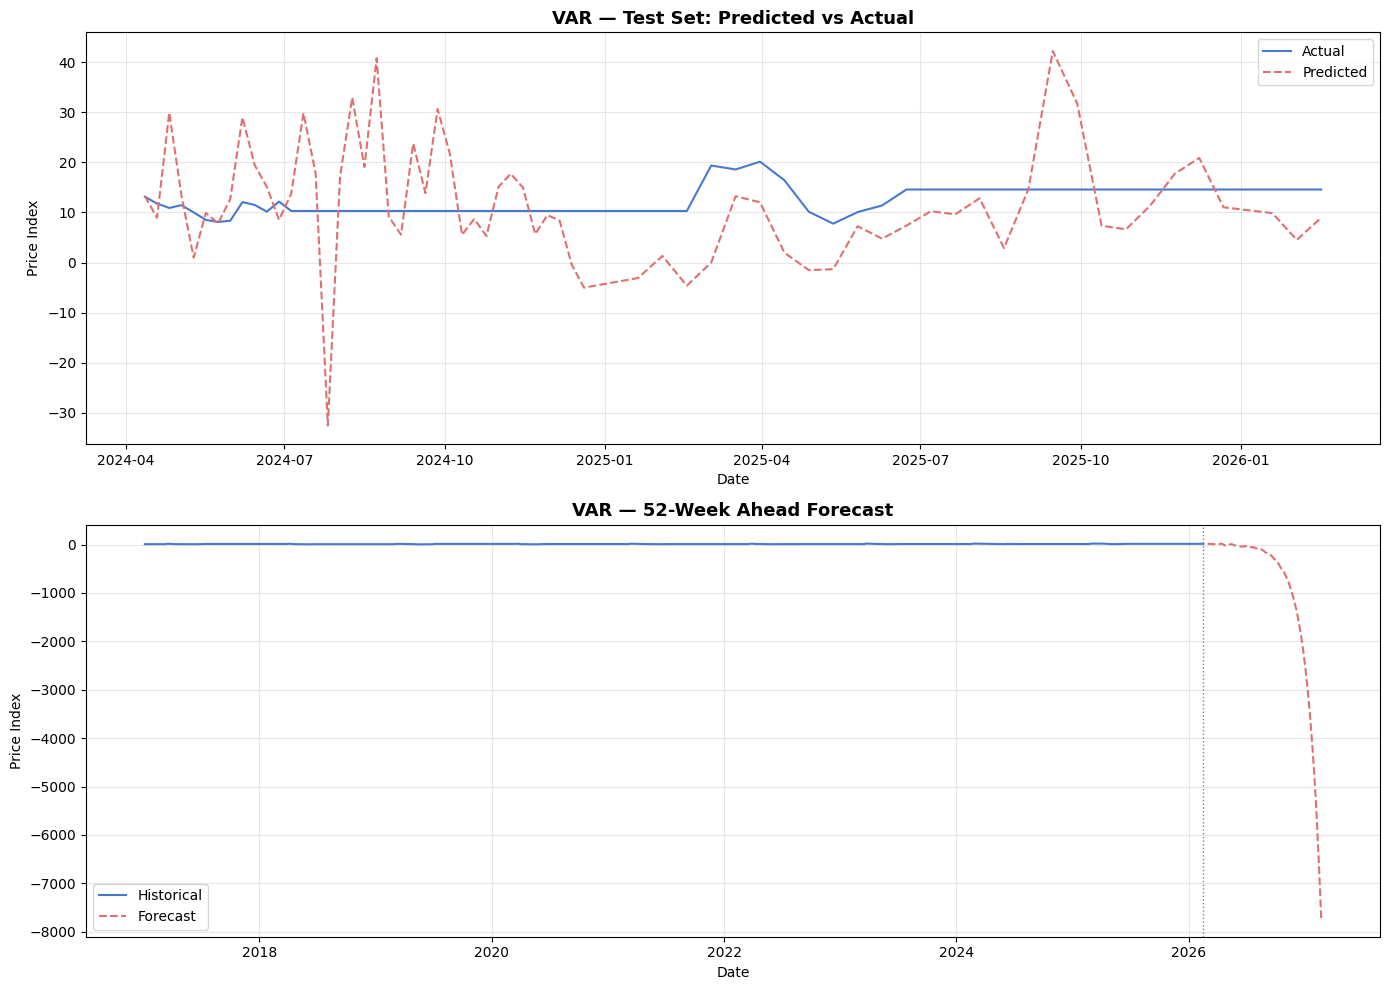

In [12]:
# ── Plot 1: Predicted vs Actual + Forecast ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(actual_test.index,   actual_test.values,   color="#4878CF", lw=1.5, label="Actual")
ax.plot(pred_test_lvl.index, pred_test_lvl.values, color="#E07070", lw=1.5, ls="--", label="Predicted")
ax.set_title("VAR — Test Set: Predicted vs Actual", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price Index")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df[TARGET_COL].index, df[TARGET_COL].values, color="#4878CF", lw=1.5, label="Historical")
ax.plot(fc_series.index,      fc_series.values,       color="#E07070", lw=1.5, ls="--", label="Forecast")
ax.axvline(df.index[-1], color="gray", ls=":", lw=1)
ax.set_title("VAR — 52-Week Ahead Forecast", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price Index")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "var_predictions_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

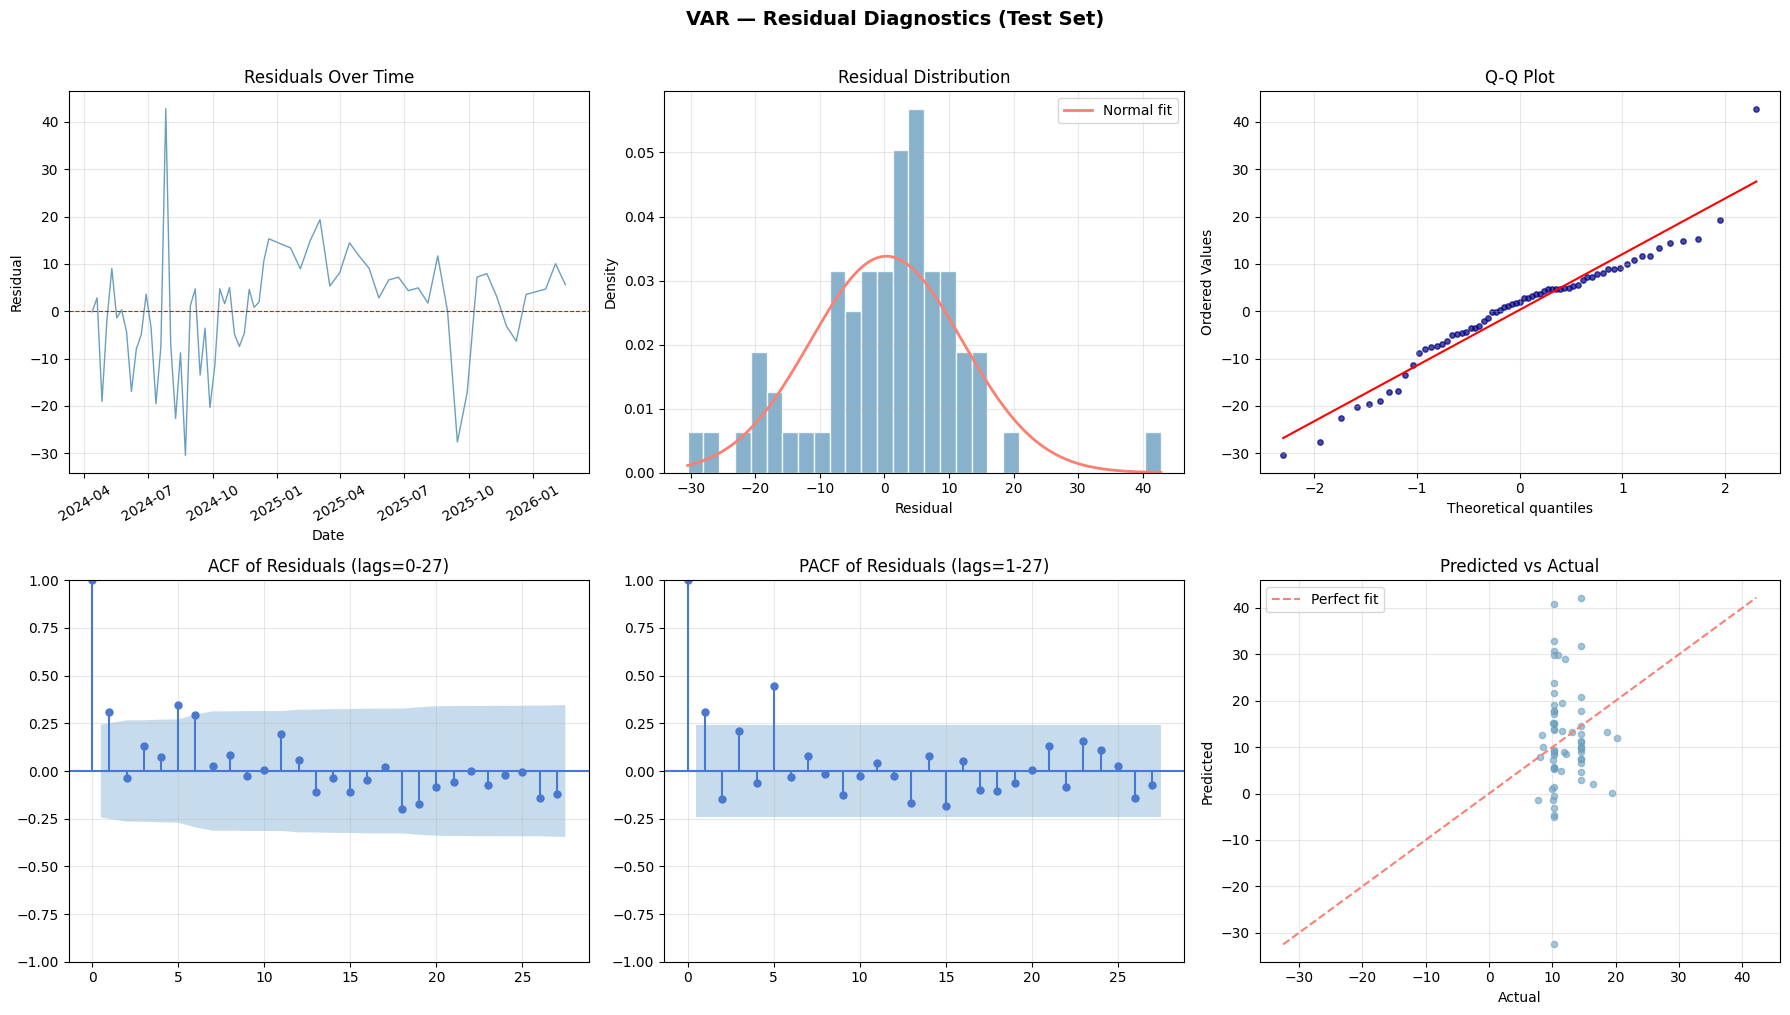

In [13]:
# ── Plot 2: Residual Diagnostics ──────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle("VAR — Residual Diagnostics (Test Set)", fontsize=14, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(actual_test.index, residuals, color="#6A9FC0", lw=1)
ax1.axhline(0, color="red", ls="--", lw=0.8)
ax1.set_title("Residuals Over Time"); ax1.set_xlabel("Date"); ax1.set_ylabel("Residual")
ax1.tick_params(axis="x", rotation=30); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuals, bins=30, color="#6A9FC0", edgecolor="white", alpha=0.8, density=True)
xr  = np.linspace(residuals.min(), residuals.max(), 200)
ax2.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), color="salmon", lw=2, label="Normal fit")
ax2.set_title("Residual Distribution"); ax2.set_xlabel("Residual"); ax2.set_ylabel("Density")
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist="norm")
ax3.scatter(osm, osr, color="navy", s=15, alpha=0.7)
ax3.plot(osm, slope * np.array(osm) + intercept, color="red", lw=1.5)
ax3.set_title("Q-Q Plot"); ax3.set_xlabel("Theoretical quantiles"); ax3.set_ylabel("Ordered Values")
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
plot_acf(residuals, lags=27, ax=ax4, title="ACF of Residuals (lags=0-27)",
         color="#4878CF", vlines_kwargs={"colors": "#4878CF"})
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
plot_pacf(residuals, lags=27, ax=ax5, title="PACF of Residuals (lags=1-27)",
          color="#4878CF", vlines_kwargs={"colors": "#4878CF"}, method="ywm")
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(actual_test.values, pred_test_lvl.values, color="#6A9FC0", s=20, alpha=0.6)
lims = [min(actual_test.min(), pred_test_lvl.min()), max(actual_test.max(), pred_test_lvl.max())]
ax6.plot(lims, lims, color="salmon", ls="--", lw=1.5, label="Perfect fit")
ax6.set_title("Predicted vs Actual"); ax6.set_xlabel("Actual"); ax6.set_ylabel("Predicted")
ax6.legend(); ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "var_residual_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
pd.DataFrame({
    "date":      actual_test.index,
    "actual":    actual_test.values,
    "predicted": pred_test_lvl.values,
    "residual":  residuals,
}).to_csv(RESULTS_DIR / "var_test_predictions.csv", index=False)

pd.DataFrame({
    "date":           fc_series.index,
    "forecast_price": fc_series.values,
}).to_csv(RESULTS_DIR / "var_52week_forecast.csv", index=False)

print("\n✓ Saved: var_test_predictions.csv")
print("✓ Saved: var_52week_forecast.csv")


✓ Saved: var_test_predictions.csv
✓ Saved: var_52week_forecast.csv


## VAR Model — Results Write-Up

### Model Overview

The VAR model was fit with an AIC-selected lag order of 12 weeks across 6 endogenous variables (fruit & vegetable price index, fuel price, CPI, API, fertiliser, and SPPI), yielding 7,525 parameters. This is a substantially over-parameterised model relative to the likely training sample size — with 6 variables and 12 lags, the VAR estimates 6 × (6 × 12 + 1) = 438 coefficients per equation, which for a weekly dataset spanning a few years creates serious degrees-of-freedom pressure. The results throughout reflect this.

---

### Training Collapse

The most immediate red flag is the train set metrics: RMSE, MAE, MASE, and MAPE all return exactly 0.0000. This is not genuine performance — it is a symptom of **perfect in-sample fit caused by severe overfitting**. With 7,525 parameters estimated on a training set that likely contains only a few hundred observations, the VAR has effectively memorised the training data. The model has zero generalisation at this stage, which the validation and test results confirm immediately.

---

### Predictive Performance

| Split | RMSE | MAE | MAPE |
|-------|------|-----|------|
| Train | 0.0000 | 0.0000 | 0.00% |
| Val | 11.2978 | 8.5099 | 83.14% |
| Test | 11.8054 | 8.7977 | 76.58% |

The collapse from perfect train performance to 76–83% MAPE on held-out data is one of the starkest train-test gaps possible. The model is off by roughly three-quarters of the actual price level on average across the test set, making it practically unusable for forecasting in its current form. The MASE values of 17–18 are particularly damning — the model is nearly 18 times worse than a naïve random walk baseline, which is the minimum bar any forecasting model should clear.

Looking at the predicted vs. actual plot, the predictions oscillate wildly between roughly -30 and +40 while the actual series moves smoothly between 10 and 20. The model is not tracking the target — it is producing noise driven by the instability of heavily parameterised lag coefficients.

---

### Forecast Explosion

The 52-week forecast is non-functional: starting near 0 and plummeting to **-7,715** by week 52. This is a classic sign of an **unstable VAR** — at least one eigenvalue of the companion matrix lies outside the unit circle, meaning the system is explosive rather than mean-reverting. In practice, this happens when the lag coefficients are poorly identified due to overfitting, causing the recursive forecast to amplify errors exponentially with each step. Any 52-week forecast from this model should be disregarded entirely.

---

### Residual Diagnostics

The residual analysis confirms the model's fundamental inadequacy on every dimension. The **Ljung-Box test** (p = 0.012) rejects the null of no autocorrelation, meaning substantial temporal structure remains in the residuals that the VAR failed to capture — a direct contradiction of what a correctly specified VAR should achieve. The **Jarque-Bera test** also rejects normality (p = 0.008), driven by excess kurtosis of 4.89, indicating heavy tails from the large prediction errors around the mid-2024 volatility period visible in the residuals-over-time plot.

The ACF and PACF plots show significant spikes at lags 1, 5, and 6, well outside the confidence bands — further evidence of unexplained autocorrelation structure. The predicted vs. actual scatter is essentially a cloud with no discernible linear relationship, and the Q-Q plot shows severe deviation from normality at both tails.

The residual mean of 0.31 with a standard deviation of 11.80 — against a target price index that appears to range between roughly 8 and 20 — represents residual noise nearly as large as the signal itself.

---

### Root Cause & Recommendations

The VAR's failure here is primarily architectural rather than a data problem. Three compounding issues are responsible:

**Overfitting from excessive parameters.** Lag 12 with 6 variables produces far more coefficients than the training sample can reliably support. Constraining the lag to 1 or 2 (which BIC and HQIC both selected) would reduce parameters by 80–90% and likely stabilise the model substantially.

**Instability from undifferenced or poorly differenced series.** The explosive forecast strongly suggests at least one variable was not sufficiently differenced or that the cointegration structure was not accounted for. A **VECM (Vector Error Correction Model)** would be more appropriate if the series are cointegrated, as it imposes long-run equilibrium constraints that prevent explosive behaviour.

**Scale mismatch across variables.** With variables on very different scales (price index ~10–20, CPI ~100+, fuel price in pence per litre), standardising inputs before fitting or using a more robust lag selection criterion like BIC (which selected lag 1) would help regularise the coefficient estimates.

The immediate practical fix is to refit with `best_lag = 1` by overriding the AIC selection, recheck stationarity more carefully, and consider whether a VECM or a simpler univariate ARIMAX with the macro variables as exogenous regressors would be a more honest benchmark against S-Mamba.